In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-10 19:43:28.979769


careful more than one adata

# Dual-innervating

In [2]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [3]:
plt.rcParams['figure.figsize'] = (4,4)
plt.rcParams["figure.dpi"] = 150

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04b_reclustered"
output_dir = BASE_DIR / "2025-12-10_meeting"

output_dir.mkdir(parents=True, exist_ok=True)

input_file = input_dir / "neurons-seurat.h5ad"

In [5]:
sc.settings.figdir = output_dir

In [6]:
adata = sc.read_h5ad(input_file)
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [7]:
adata.X = adata.layers['log1p'].copy()

### Plot

In [8]:
plt.rcdefaults()
plt.rcParams["figure.dpi"] = 150

### Top Marker Genes

In [9]:
adata.obs.seurat_labels.value_counts()

seurat_labels
CGRP-Gamma                    6186
Nonpeptidergic nociceptors    3513
CGRP-Eta                      1963
CGRP-Zeta                     1493
Abeta-RA-LTMR                 1463
Abeta-Field                   1452
C-LTMR                        1402
Adelta-LTMR                   1020
CGRP-Theta                     868
Proprioceptors                 864
TrpM8                          650
CGRP-Epsilion                  609
Sst                            554
CGRP-Alpha                     245
CGRP-Beta                      129
Name: count, dtype: int64

In [10]:
adata.obs["seurat_labels"] = adata.obs["seurat_labels"].astype("category")
adata.obs["seurat_labels"] = adata.obs["seurat_labels"].cat.remove_unused_categories()

In [11]:
sc.tl.rank_genes_groups(adata, groupby="seurat_labels", method="wilcoxon")

In [12]:
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,Abeta-Field,Hapln1,52.491867,3.370802,0.000000e+00,0.000000e+00
1,Abeta-Field,Cntn1,49.403072,1.782196,0.000000e+00,0.000000e+00
2,Abeta-Field,Endod1,46.375473,1.185746,0.000000e+00,0.000000e+00
3,Abeta-Field,Hopx,45.988441,2.061731,0.000000e+00,0.000000e+00
4,Abeta-Field,Gfra1,44.374371,1.716223,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...
7120,TrpM8,Scn10a,-27.428131,-2.618770,1.266999e-165,2.865831e-164
7121,TrpM8,F2rl2,-28.468809,-2.226695,2.851323e-178,7.524323e-177
7122,TrpM8,Resp18,-28.797789,-2.631424,2.286224e-182,6.387980e-181
7123,TrpM8,Asic2,-30.763878,-1.723815,7.976066e-208,3.788631e-206


In [13]:
log2fc_threshold = 2
pval_threshold = 0.05
markers_filtered = markers[
    (markers["logfoldchanges"] > log2fc_threshold)
    & (markers["pvals_adj"] < pval_threshold)
].copy()

#### Extract top 5 genes for each group

In [14]:
top_genes = (
    markers_filtered.sort_values(
        by=["group", "logfoldchanges"], ascending=[True, False]
    )  # Sort by group and log2FC
    .groupby("group")["names"]  
    .head(5)  
    .tolist()  
)

/tmp/ipykernel_13285/2505543662.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("group")["names"]


In [15]:
plt.rcParams["font.size"] = 15

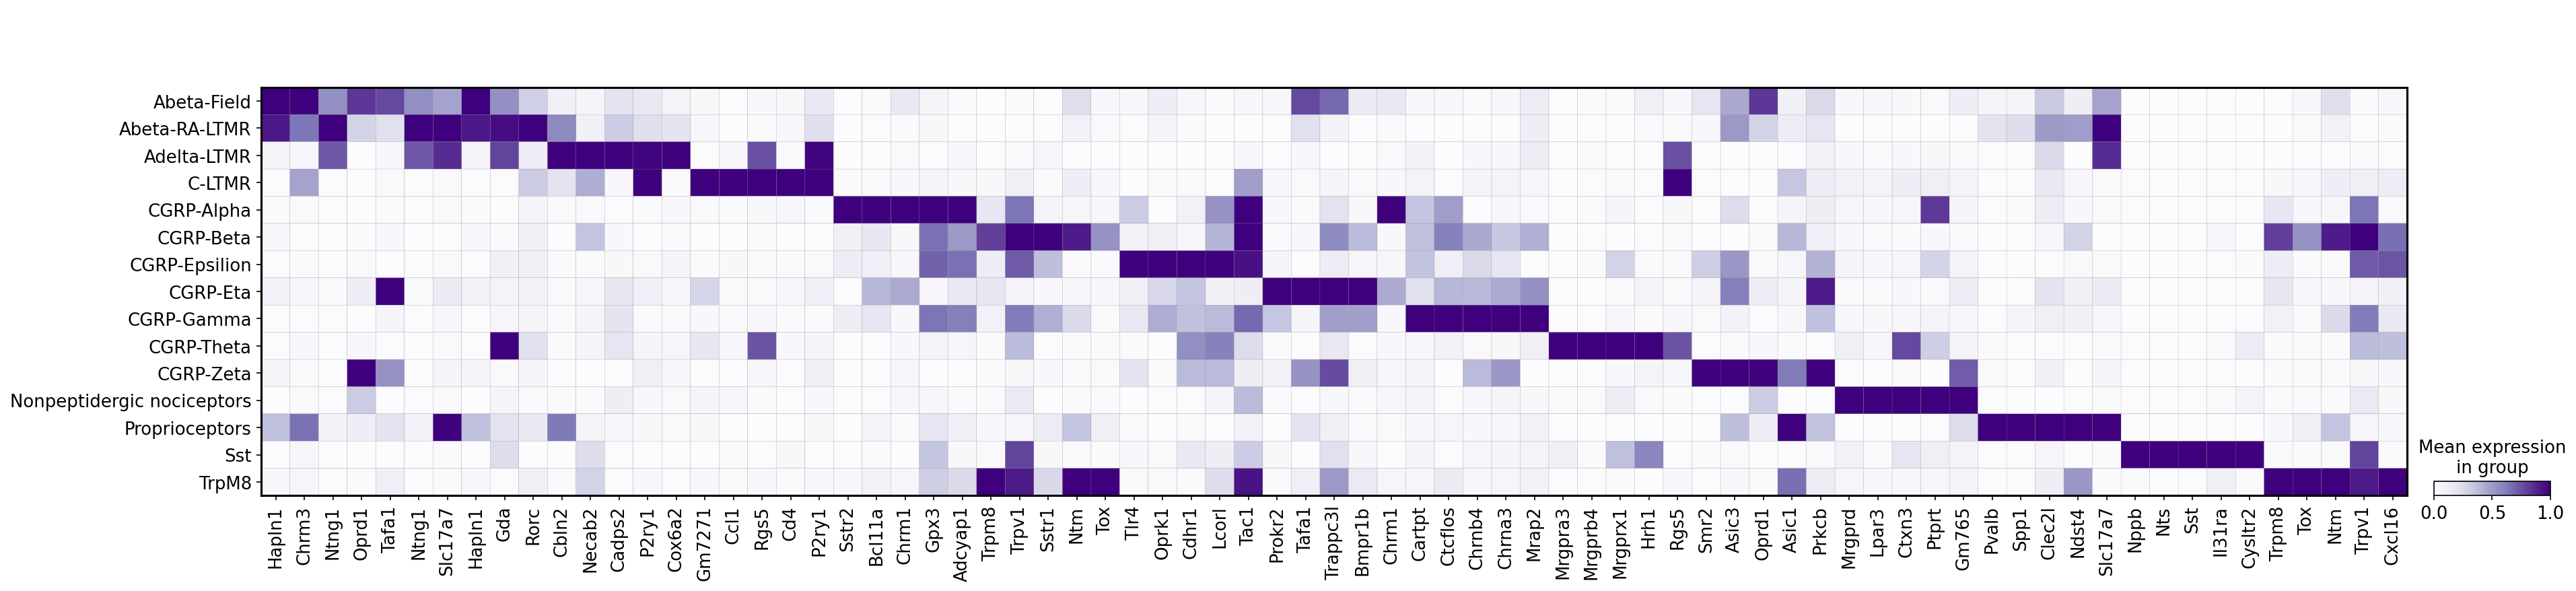

In [16]:
sc.pl.matrixplot(
    adata,
    var_names=top_genes,
    groupby="seurat_labels",
    title="",
    standard_scale = 'var',
   # save = '_ExtdFig8d.pdf',
    cmap = 'Purples'
)

In [17]:
markers_filtered.to_csv(f"{output_dir}/marker-genes-filtered.tsv", 
                        sep="\t", index=False)

markers.to_csv(f"{output_dir}/marker-genes-full.tsv", 
                        sep="\t", index=False)

# Dual-hi marker genes

In [18]:
adata.obs.EGFP_dTomato_dual_hi.value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

In [19]:
adata.obs["EGFP_dTomato_dual_hi"] = adata.obs["EGFP_dTomato_dual_hi"].astype(str)
sc.tl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")


In [20]:
markers = sc.get.rank_genes_groups_df(adata, group=None)
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,False,Rph3a,5.348411,3.061578,8.873009e-08,0.000004
1,False,Tnfrsf11a,4.356625,2.419328,1.320832e-05,0.000251
2,False,Nptx2,4.279661,3.553002,1.871779e-05,0.000325
3,False,Gabra1,4.238811,5.394399,2.247063e-05,0.000368
4,False,Nmb,3.961234,2.575184,7.456332e-05,0.001073
...,...,...,...,...,...,...
945,True,Nmb,-3.961234,-2.575184,7.456332e-05,0.001073
946,True,Gabra1,-4.238811,-5.394399,2.247063e-05,0.000368
947,True,Nptx2,-4.279661,-3.553002,1.871779e-05,0.000325
948,True,Tnfrsf11a,-4.356625,-2.419328,1.320832e-05,0.000251


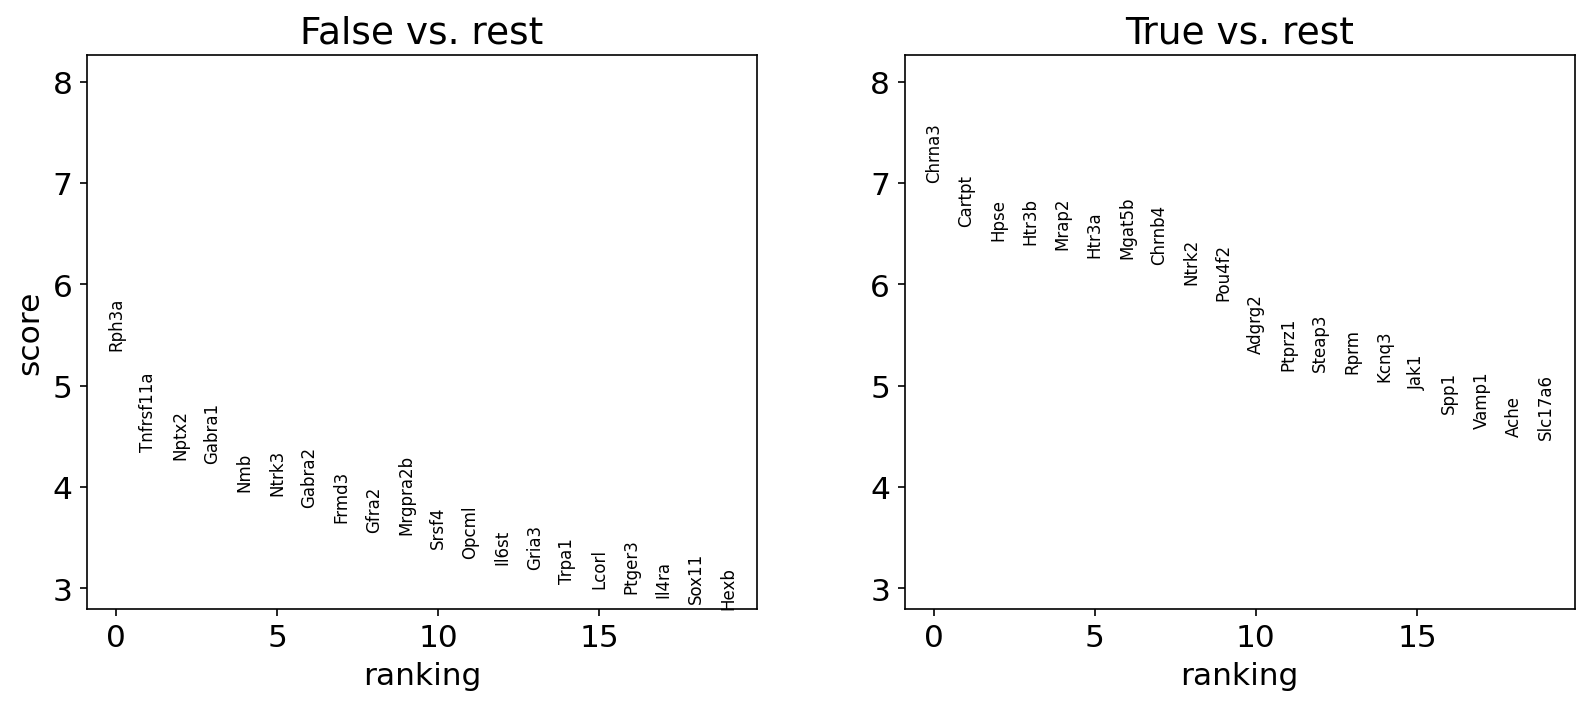

In [21]:
sc.pl.rank_genes_groups(adata, groupby="EGFP_dTomato_dual_hi", method="wilcoxon")

In [22]:
#log2fc_threshold = 2
#pval_threshold = 0.05
#markers_filtered = markers[
#    (markers["logfoldchanges"] > log2fc_threshold)
#    & (markers["pvals_adj"] < pval_threshold)
#].copy()

#### Extract top 5 genes for each group

In [23]:
top_genes = (
    markers.groupby("group")["names"]
    .head(10)
    .tolist()
)

/tmp/ipykernel_13285/3380004514.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  markers.groupby("group")["names"]


In [24]:
plt.rcParams["font.size"] = 15

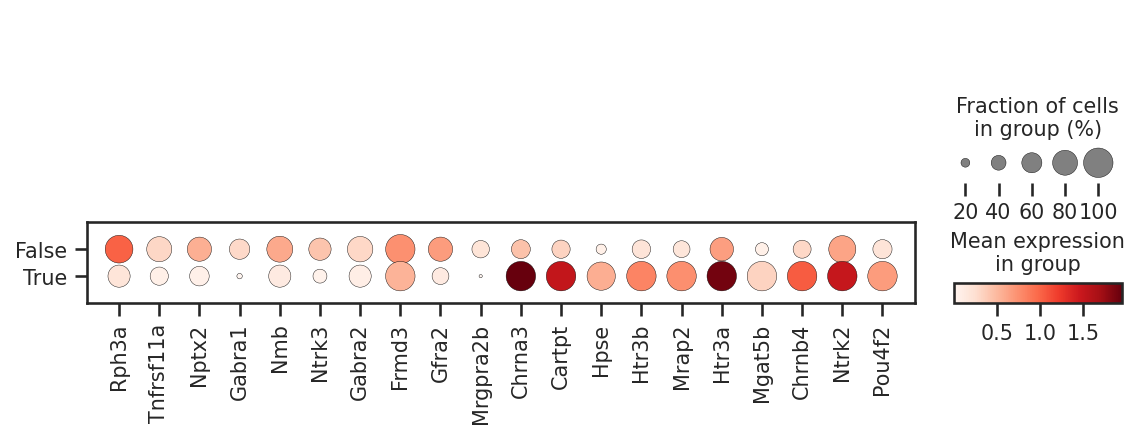

In [43]:
sc.pl.dotplot(
    adata,
    var_names=top_genes,
    groupby="EGFP_dTomato_dual_hi",
    title="",
    #standard_scale = 'var',
   # save = '_ExtdFig8d.pdf',
    cmap = 'Reds'
)

In [26]:
markers_filtered.to_csv(f"{output_dir}/target-signature-filtered.tsv", 
                        sep="\t", index=False)

markers.to_csv(f"{output_dir}/target-signature-full.tsv", 
                        sep="\t", index=False)

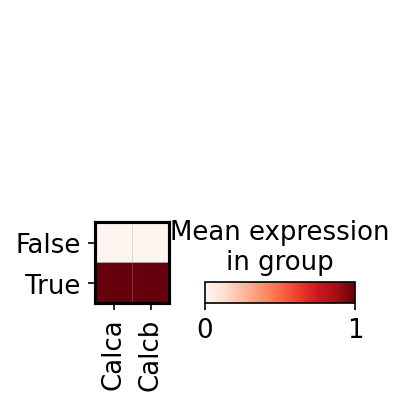

In [27]:
sc.pl.matrixplot(
    adata,
    var_names=['Calca','Calcb'],
    groupby="EGFP_dTomato_dual_hi",
    title="",
    standard_scale = 'var',
   # save = '_ExtdFig8d.pdf',
    cmap = 'Reds'
)

In [28]:
def plot_expression_barplot(adata, genes, groupby='group', sample_id_col='sample_id', title=""):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    custom_palette = {
        'False': 'black',
        'True': 'red'
    }

    expression_df = adata.to_df()[genes].join(adata.obs[[groupby, sample_id_col]])
    mean_expr = expression_df.groupby([groupby, sample_id_col]).mean().reset_index()

    mean_expr_melted = mean_expr.melt(
        id_vars=[groupby, sample_id_col],
        var_name='Gene',
        value_name='Mean Expression'
    )

    fig, ax = plt.subplots(figsize=(6 + len(genes)*0.6, 5))

    sns.barplot(
        data=mean_expr_melted,
        x='Gene',
        y='Mean Expression',
        hue=groupby,
        palette=custom_palette,
        ci=None,
        capsize=0.0,
        alpha=0.6,
        ax=ax
    )

    sns.stripplot(
        data=mean_expr_melted,
        x='Gene',
        y='Mean Expression',
        hue=groupby,
        dodge=True,
        jitter=True,
        marker="o",
        edgecolor="black",
        linewidth=0.6,
        size=6,
        alpha=0.9,
        palette=custom_palette,
        ax=ax
    )

    ax.set_xticks(range(len(genes)))
    ax.set_xticklabels(genes, rotation=45, fontsize=18)
    ax.set_ylabel("Mean expression", fontsize=20)
    ax.set_xlabel("")
    ax.set_title(title, fontsize=22)
    ax.tick_params(axis='y', labelsize=18)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    new_handles, new_labels = [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            new_handles.append(h)
            new_labels.append(l)
            seen.add(l)

    ax.legend(new_handles, new_labels,
              title=groupby.capitalize(), title_fontsize=18, fontsize=15,
              loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

    plt.tight_layout()
    return fig

/tmp/ipykernel_13285/1944077446.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr = expression_df.groupby([groupby, sample_id_col]).mean().reset_index()
/tmp/ipykernel_13285/1944077446.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


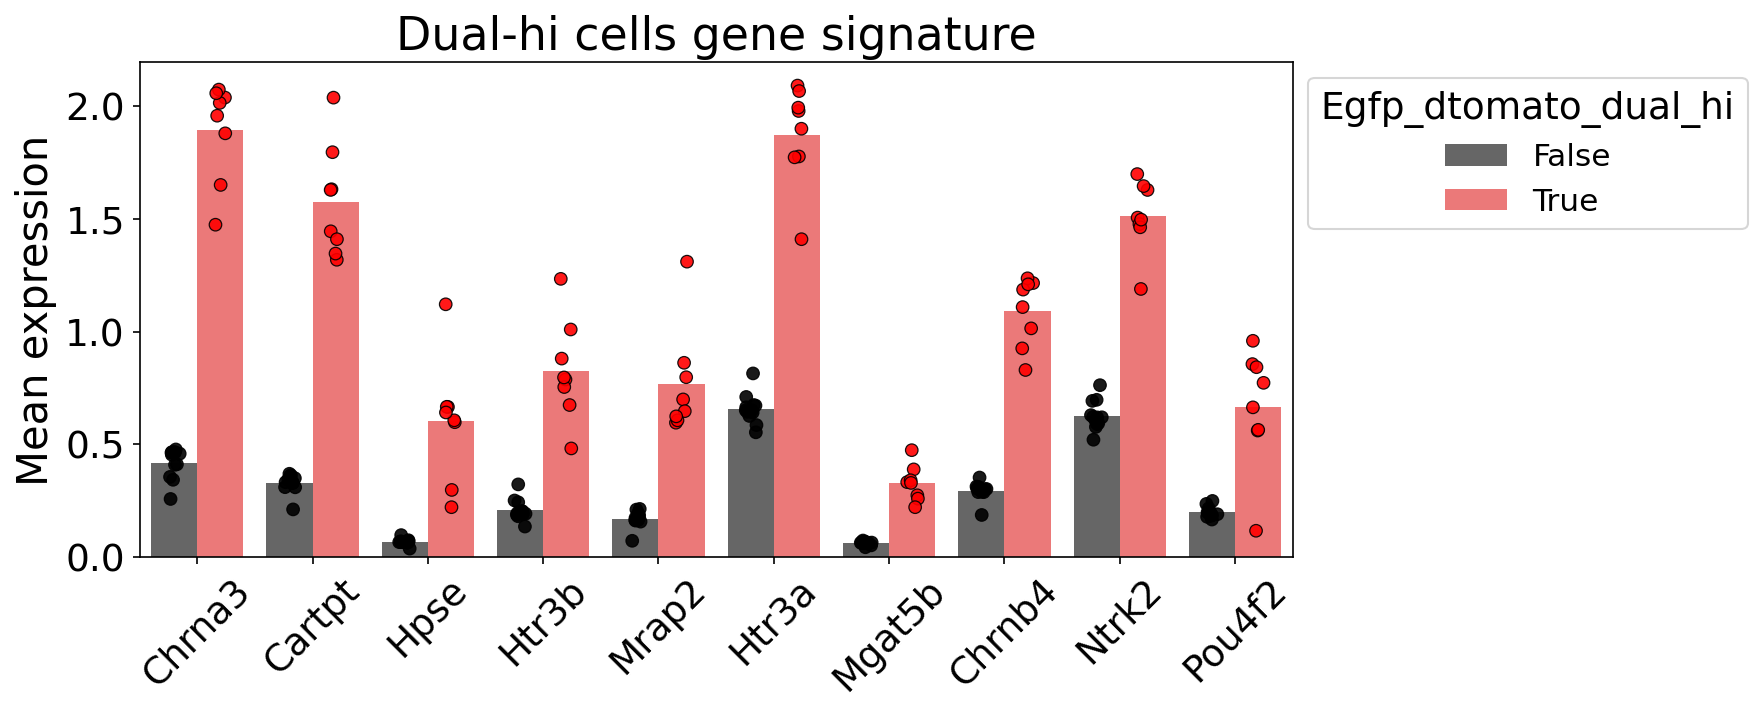

In [29]:
genes = ['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Chrnb4', 'Ntrk2', 'Pou4f2']
fig = plot_expression_barplot(
    adata,
    genes=genes,
    groupby='EGFP_dTomato_dual_hi',
    sample_id_col='sample_id',
    title='Dual-hi cells gene signature'
)

# Save to output_dir
#save_path = os.path.join(output_dir, "isc_expression.pdf")
#fig.savefig(save_path, bbox_inches='tight')

In [30]:
def kde_grid_plot(
    adata,
    genes,
    group_col="EGFP_dTomato_dual_hi",   # group column to compare True vs False
    ncols=5,                             # number of columns in grid
    figsize=(12, 6),
    gene_fontsize=14                     # NEW: control gene title size
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    import math

    sns.set_theme(style="ticks")

    # --- Robust conversion of group_col to boolean ---
    raw_group = adata.obs[group_col]

    if isinstance(raw_group.dtype, pd.CategoricalDtype):
        group_bool = raw_group.astype(str) == "True"
    elif raw_group.dtype == bool:
        group_bool = raw_group.values
    else:
        group_bool = raw_group.astype(str).str.lower().isin(["true", "1", "yes"]).values

    # Extract expression values for each gene
    df = adata.to_df()[genes]

    n = len(genes)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, gene in enumerate(genes):
        ax = axes[i]
        x = df[gene].values

        # KDE for False (black)
        sns.kdeplot(
            x[~group_bool],
            ax=ax,
            fill=True,
            color="black",
            alpha=0.25,
            linewidth=3,
            label="False"
        )

        # KDE for True (blue)
        sns.kdeplot(
            x[group_bool],
            ax=ax,
            fill=True,
            color="blue",
            alpha=0.5,
            linewidth=2,
            label="True"
        )

        # --- Italicized, configurable gene name ---
        ax.set_title(
            f"$\\it{{{gene}}}$",
            fontsize=gene_fontsize
        )

        ax.set_yticks([])
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=8)

    # Hide unused axes (if any)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    sns.despine()
    plt.tight_layout()

    return fig

In [31]:
genes

['Chrna3',
 'Cartpt',
 'Hpse',
 'Htr3b',
 'Mrap2',
 'Htr3a',
 'Mgat5b',
 'Chrnb4',
 'Ntrk2',
 'Pou4f2']

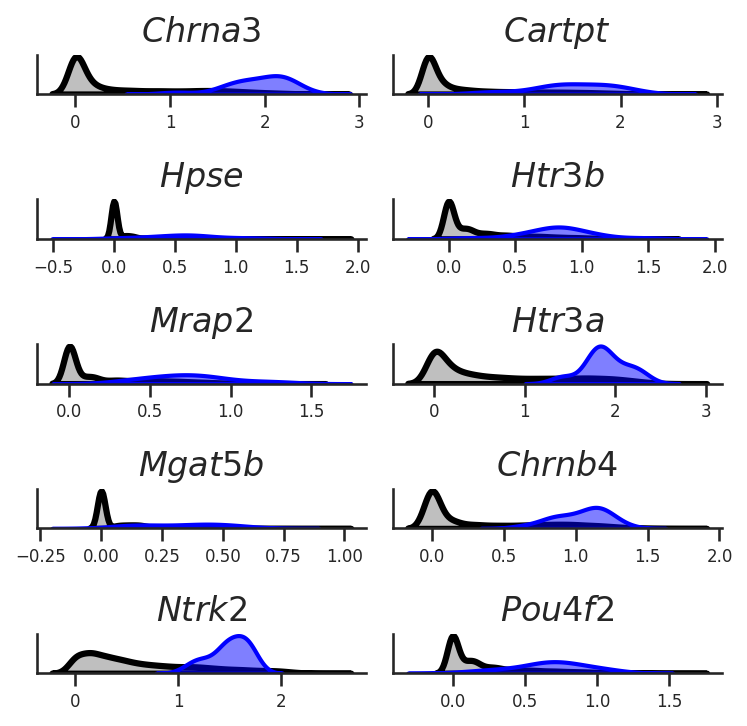

In [32]:
fig = kde_grid_plot(
    adata,
    genes=genes,
    group_col="EGFP_dTomato_dual_hi",
    ncols=2,
    figsize=(5, 5),
    gene_fontsize = 16
)

In [33]:
genes_subset = ['Chrna3',
                 'Chrnb4',
                 'Ntrk2',
 'Cartpt', 'Htr3a', 'Htr3b', ]
# 'Hpse',

# 'Mgat5b',
 #'Mrap2']
# 'Pou4f2']

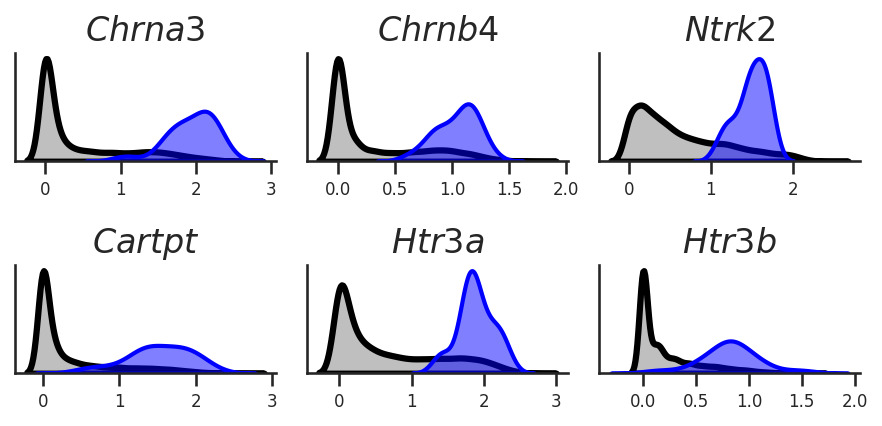

In [34]:
fig = kde_grid_plot(
    adata,
    genes=genes_subset,
    group_col="EGFP_dTomato_dual_hi",
    ncols=3,
    figsize=(6, 3),
    gene_fontsize = 16
)

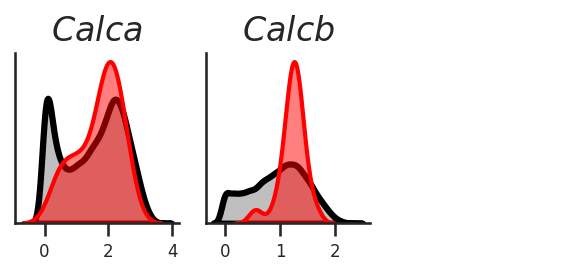

In [35]:
def kde_grid_plot(
    adata,
    genes,
    group_col="EGFP_dTomato_dual_hi",   # group column to compare True vs False
    ncols=5,                             # number of columns in grid
    figsize=(12, 6),
    gene_fontsize=14                     # NEW: control gene title size
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import pandas as pd
    import math

    sns.set_theme(style="ticks")

    # --- Robust conversion of group_col to boolean ---
    raw_group = adata.obs[group_col]

    if isinstance(raw_group.dtype, pd.CategoricalDtype):
        group_bool = raw_group.astype(str) == "True"
    elif raw_group.dtype == bool:
        group_bool = raw_group.values
    else:
        group_bool = raw_group.astype(str).str.lower().isin(["true", "1", "yes"]).values

    # Extract expression values for each gene
    df = adata.to_df()[genes]

    n = len(genes)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, gene in enumerate(genes):
        ax = axes[i]
        x = df[gene].values

        # KDE for False (black)
        sns.kdeplot(
            x[~group_bool],
            ax=ax,
            fill=True,
            color="black",
            alpha=0.25,
            linewidth=3,
            label="False"
        )

        # KDE for True (blue)
        sns.kdeplot(
            x[group_bool],
            ax=ax,
            fill=True,
            color="red",
            alpha=0.5,
            linewidth=2,
            label="True"
        )

        # --- Italicized, configurable gene name ---
        ax.set_title(
            f"$\\it{{{gene}}}$",
            fontsize=gene_fontsize
        )

        ax.set_yticks([])
        ax.set_ylabel("")
        ax.tick_params(axis="x", labelsize=8)

    # Hide unused axes (if any)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    sns.despine()
    plt.tight_layout()

    return fig


fig = kde_grid_plot(
    adata,
    genes=['Calca', 'Calcb'],
    group_col="EGFP_dTomato_dual_hi",
    ncols=3,
    figsize=(4, 2),
    gene_fontsize = 16
)

In [36]:
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [37]:
# Build table
df = pd.DataFrame({
    "barcode": adata.obs.index,
    "seurat_label": adata.obs["seurat_labels"],
    "scanvi_label": adata.obs["scanvi_labels"],
    "sample_id": adata.obs["sample_id"],
    "confidence": adata.obs["confidence"],
    "dual_pos": adata.obs["EGFP_dTomato_dual_hi"].astype(bool)
})

# Filter: dual-innervating AND confidence not NaN
df_dual = df[
    df["dual_pos"] &
    df["confidence"].notna()
]

df_dual[["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
agbmnepe-1,agbmnepe-1,CGRP-Gamma,CGRP-Gamma,High
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High
aefmnmje-1,aefmnmje-1,CGRP-Gamma,CGRP-Gamma,High
bcmkpnkd-1,bcmkpnkd-1,CGRP-Alpha,CGRP-Alpha,Low


In [38]:
adata

AnnData object with n_obs × n_vars = 22411 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [40]:
adata.obs["EGFP_dTomato_dual_hi"].value_counts()

EGFP_dTomato_dual_hi
False    22392
True        19
Name: count, dtype: int64

In [41]:
# Boolean masks
egfp = adata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = adata.obs["dTomato_Seq2_hi"].astype(bool)
dual = adata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table
df = pd.DataFrame({
    "barcode": adata.obs.index,
    "seurat_label": adata.obs["seurat_labels"],
    "scanvi_label": adata.obs["scanvi_labels"],
    "sample_id": adata.obs["sample_id"],
    "confidence": adata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

# Summary
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
aaadagcf-1,aaadagcf-1,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,NaN
aaaihgjh-1,aaaihgjh-1,Adelta-LTMR,Adelta-LTMR,NaN
aabcohae-1,aabcohae-1,Adelta-LTMR,Adelta-LTMR,NaN
aabdncpn-1,aabdncpn-1,Proprioceptors,Proprioceptors,NaN
aacblkbe-1,aacblkbe-1,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,NaN
...,...,...,...,...
ncikkhpf-1,ncikkhpf-1,CGRP-Eta,CGRP-Eta,NaN
ncikogkk-1,ncikogkk-1,CGRP-Epsilion,CGRP-Theta,NaN
ncpkkekg-1,ncpkkekg-1,CGRP-Eta,CGRP-Eta,NaN
ndabchac-1,ndabchac-1,Abeta-Field,Abeta-Field,NaN
